I0000 00:00:1774430669.405438   20884 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774430669.445573   20884 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774430670.738356   20884 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/media/a22nicolesdc/DIURNOEXTRA/miniconda3/envs/ML/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774430672.923137   20884 cuda_platform.cc:52] failed call to cuInit: INT

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (88.00 B)

 Trainable params: 22 (88.00 B)

 Non-trainable params: 0 (0.00 B)

None
Comenzando entrenamiento...
Modelo entrenado!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0630
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
El resultado es [[103.87048]] fahrenheit!
Variables internas del modelo
[array([[-0.05351691, -0.5905383 , -0.3384638 ]], dtype=float32), array([ 2.593177 , -4.3444347, -2.8406053], dtype=float32)]
[array([[ 1.1699188 ,  0.05445791, -0.56718004],
       [ 0.18102194, -1.3219916 ,  1.492752  ],
       [-1.0842351 , -0.04773028,  0.84920347]], dtype=float32), array([ 3.9269025,  3.270806 , -3.0598345], dtype=float32)]
[array([[ 1.0507243],
       [ 1.0616605],
       [-0.6565865]], dtype=float32), array([3.5484886], dtype=float32)]


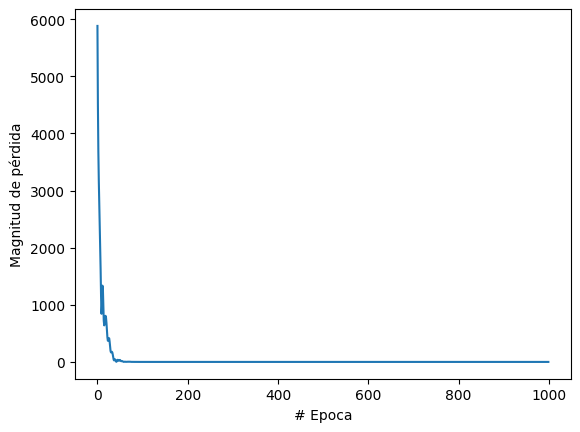

In [ ]:
# Ejemplo 1: Transformación de grados Celsius a Fahrenheit

#  importamos las clases que utilizaremos
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt

# creamos los arrays de entrada y salida.
# la capa de entrada son las features 
celsius = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit = np.array([-40, 14, 32, 46, 59, 72, 100], dtype=float)

# Creación del modelo de red neuronal

oculta1 = Dense(3, input_shape=[1]) #Parámetros: 3(neuronas)*1(dimensiones) + 3 (sesgo) = 6
oculta2 = Dense(3) # 3(neuronas)*3(neuronas capa anterior) + 3 (sesgo) = 12
salida = Dense(1) # 1(neurona)*3(neuronas capa anterior) + 1 (sesgo) = 4
model = Sequential([oculta1, oculta2, salida])

# printamos el resumen del modelo de red neuronal
print(model.summary())

# Con compile podemos ajustar nuestro modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='mean_squared_error'
)

# entrenaremos la red recibiendo por parámetro los arrays de entrada y salida, así como el número de iteraciones de aprendizaje (epochs) de entrenamiento
print("Comenzando entrenamiento...")
historial = model.fit(celsius, fahrenheit, epochs=1000, verbose=False)
print("Modelo entrenado!")

# mostramos gráficamente el resultado del entrenamiento
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])

# evaluamos el modelo
scores = model.evaluate(celsius, fahrenheit)

#probamos a hacer una predicción
proba = np.array([40.0])
resultado = model.predict(proba)
print("El resultado es " + str(resultado) + " fahrenheit!")

print("Variables internas del modelo")
print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())